# Improved Random Forest — SMOTE + Extended Features + Threshold Tuning

This notebook addresses the three core failures of the previous models:
1. **Class imbalance** — Fatality (0.27%) was never learned. Fixed with SMOTE oversampling on training data only.
2. **Weak feature set** — Added pedestrian/truck flags, vehicle count, and night-bike/moto-rush interactions.
3. **Fixed evaluation threshold** — Default 0.5 threshold ignores Fatality. We sweep thresholds and tune for recall.

Primary KPI: **Fatality recall** (missing a fatal crash is worse than a false alarm).  
Secondary KPI: Macro F1 (overall balance across all three classes).

---
## 1. Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, PrecisionRecallDisplay,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


---
## 2. Load data

In [2]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nSeverity distribution:")
dist = df['severity'].value_counts().rename({0: 'No Injury', 1: 'Injury', 2: 'Fatality'})
for label, count in dist.items():
    print(f"  {label:12s}: {count:>7,}  ({count/len(df)*100:.2f}%)")
print("\nYears:")
print(df['year'].value_counts().sort_index())

Shape: 394,751 rows x 29 columns

Severity distribution:
  No Injury   : 230,535  (58.40%)
  Injury      : 163,164  (41.33%)
  Fatality    :   1,052  (0.27%)

Years:
year
2022    103887
2023     96606
2024     91315
2025     85534
2026     17409
Name: count, dtype: int64


---
## 3. Extended feature engineering

We keep everything from the cleaner model and add:
- `pedestrian_involved` — pedestrian as a vehicle party (high fatality risk)
- `truck_involved` — large commercial vehicle present (high fatality risk)
- `num_vehicles` — how many vehicle columns are populated (1 or 2)
- `bike_dark` — bike/e-bike/scooter involved during dark hours (20:00–05:00)
- `moto_rush` — motorcycle involved during rush hour (interaction)

These target the combinations that empirically associate with fatalities.

In [3]:
df = df.copy()

# --- time and spatial bins (same as cleaner model) ---
def month_to_season(m):
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'fall'

def hour_to_period(h):
    if h < 5:  return 'late_night'
    if h < 10: return 'morning'
    if h < 15: return 'midday'
    if h < 19: return 'evening'
    return 'night'

df['season']     = df['month'].apply(month_to_season)
df['time_of_day'] = df['hour'].apply(hour_to_period)

# --- vehicle-type binary flags (carry over) ---
vt_cols = ['vehicle_type_1', 'vehicle_type_2']
df['bike_involved']       = df[vt_cols].isin(['BIKE', 'E-BIKE', 'E-SCOOTER']).any(axis=1).astype(int)
df['motorcycle_involved'] = df[vt_cols].isin(['MOTORCYCLE', 'MOPED']).any(axis=1).astype(int)
df['unknown_factor']      = df[['factor_vehicle_1', 'factor_vehicle_2']].isin(['UNSPECIFIED', 'UNKNOWN']).any(axis=1).astype(int)

# --- NEW: pedestrian and truck flags ---
PEDESTRIAN_LABELS = ['PEDESTRIAN', 'PED']
TRUCK_LABELS      = ['TRUCK', 'BOX TRUCK', 'TRACTOR TRUCK DIESEL', 'TRACTOR TRUCK GASOLINE',
                     'FLAT BED', 'GARBAGE OR REFUSE', 'DUMP', 'TANKER', 'CONCRETE MIXER']

df['pedestrian_involved'] = df[vt_cols].isin(PEDESTRIAN_LABELS).any(axis=1).astype(int)
df['truck_involved']      = df[vt_cols].isin(TRUCK_LABELS).any(axis=1).astype(int)

# --- NEW: number of vehicles in collision ---
df['num_vehicles'] = df['vehicle_type_1'].notna().astype(int) + df['vehicle_type_2'].notna().astype(int)

# --- NEW: interaction features ---
dark_hours = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
df['bike_dark']  = df['bike_involved'] * dark_hours
df['moto_rush']  = df['motorcycle_involved'] * df['is_rush_hour']

# --- geospatial grid cell ---
df['lat_bin']  = pd.qcut(df['latitude'],  q=5, labels=['lat0','lat1','lat2','lat3','lat4'], duplicates='drop')
df['lon_bin']  = pd.qcut(df['longitude'], q=5, labels=['lon0','lon1','lon2','lon3','lon4'], duplicates='drop')
df['grid_cell'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

new_features = ['pedestrian_involved', 'truck_involved', 'num_vehicles', 'bike_dark', 'moto_rush']
print("New features added:", new_features)
print("\nFatality rate by pedestrian_involved:")
print(df.groupby('pedestrian_involved')['severity'].apply(lambda s: (s==2).mean()).rename({0:'not involved', 1:'involved'}))
print("\nFatality rate by truck_involved:")
print(df.groupby('truck_involved')['severity'].apply(lambda s: (s==2).mean()).rename({0:'not involved', 1:'involved'}))

New features added: ['pedestrian_involved', 'truck_involved', 'num_vehicles', 'bike_dark', 'moto_rush']

Fatality rate by pedestrian_involved:
pedestrian_involved
not involved    0.002665
involved        0.000000
Name: severity, dtype: float64

Fatality rate by truck_involved:
truck_involved
not involved    0.002515
involved        0.004682
Name: severity, dtype: float64


---
## 4. Define feature set

In [4]:
DROP_COLS = [
    'severity',
    'num_injured', 'num_killed',
    'number_of_pedestrians_injured', 'number_of_pedestrians_killed',
    'number_of_cyclist_injured',     'number_of_cyclist_killed',
    'number_of_motorist_injured',    'number_of_motorist_killed',
    'collision_id', 'crash_date', 'crash_time',
    'on_street_name', 'cross_street_name', 'location',
    'zip_code', 'year',
    'latitude', 'longitude', 'lat_bin', 'lon_bin',
]
feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f"Total features: {len(feature_cols)}")
print(feature_cols)

X = df[feature_cols].copy()
y = df['severity'].copy()

Total features: 21
['borough', 'factor_vehicle_1', 'factor_vehicle_2', 'vehicle_type_1', 'vehicle_type_2', 'month', 'day_of_week', 'hour', 'is_weekend', 'is_rush_hour', 'season', 'time_of_day', 'bike_involved', 'motorcycle_involved', 'unknown_factor', 'pedestrian_involved', 'truck_involved', 'num_vehicles', 'bike_dark', 'moto_rush', 'grid_cell']


---
## 5. Time-based train/test split

Train on 2022–2024, test on 2025. Same strategy as prior models for fair comparison.

In [5]:
train_mask = df['year'].isin([2022, 2023, 2024])
test_mask  = df['year'] == 2025

X_train_raw, y_train = X[train_mask].copy(), y[train_mask].copy()
X_test_raw,  y_test  = X[test_mask].copy(),  y[test_mask].copy()

print(f"Train: {len(X_train_raw):,} rows")
print(f"Test:  {len(X_test_raw):,} rows")
print("\nTrain severity counts:")
print(y_train.value_counts().rename({0:'No Injury', 1:'Injury', 2:'Fatality'}))
print("\nTest severity counts:")
print(y_test.value_counts().rename({0:'No Injury', 1:'Injury', 2:'Fatality'}))

Train: 291,808 rows
Test:  85,534 rows

Train severity counts:
severity
No Injury    171772
Injury       119235
Fatality        801
Name: count, dtype: int64

Test severity counts:
severity
No Injury    48121
Injury       37199
Fatality       214
Name: count, dtype: int64


---
## 6. Preprocess categorical features

Cap rare categories at top 12, one-hot encode, align test columns to train.

In [6]:
def cap_top_n(series, n=12):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), 'OTHER')

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

for col in ['vehicle_type_1', 'vehicle_type_2', 'factor_vehicle_1', 'factor_vehicle_2']:
    if col in X_train.columns:
        X_train[col] = cap_top_n(X_train[col], n=12)
        X_test[col]  = X_test[col].where(X_test[col].isin(X_train[col].unique()), 'OTHER')

CAT_COLS = [
    'borough', 'day_of_week', 'season', 'time_of_day', 'grid_cell',
    'vehicle_type_1', 'vehicle_type_2', 'factor_vehicle_1', 'factor_vehicle_2'
]
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]

X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=CAT_COLS, drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

# fix any lingering category dtype
for df_ in [X_train, X_test]:
    for col in df_.select_dtypes(include='category').columns:
        df_[col] = df_[col].astype(float)

X_train = X_train.fillna(0).astype(float)
X_test  = X_test.fillna(0).astype(float)

print(f"X_train after encoding: {X_train.shape}")
print(f"X_test  after encoding: {X_test.shape}")

X_train after encoding: (291808, 102)
X_test  after encoding: (85534, 102)


---
## 7. Apply SMOTE — fix class imbalance on training data

SMOTE creates synthetic Fatality samples by interpolating between real ones in feature space.  
We apply it **only on the training set** — the test set is never touched.  

Strategy: oversample Fatality to 8,000 (≈10× from ~780), keep No Injury and Injury at natural sizes.

In [7]:
print("Before SMOTE:")
for cls, name in {0: 'No Injury', 1: 'Injury', 2: 'Fatality'}.items():
    print(f"  {name}: {(y_train == cls).sum():,}")

fatality_train_count = (y_train == 2).sum()
smote_target = max(8000, fatality_train_count)  # at least 8000 Fatality samples

sampling_strategy = {2: smote_target}  # only oversample Fatality
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
for cls, name in {0: 'No Injury', 1: 'Injury', 2: 'Fatality'}.items():
    n = (y_train_sm == cls).sum()
    print(f"  {name}: {n:,}  ({n/len(y_train_sm)*100:.1f}%)")
print(f"\nTotal training rows: {len(X_train_sm):,}")

Before SMOTE:
  No Injury: 171,772
  Injury: 119,235
  Fatality: 801



After SMOTE:
  No Injury: 171,772  (57.4%)
  Injury: 119,235  (39.9%)
  Fatality: 8,000  (2.7%)

Total training rows: 299,007


---
## 8. Cross-validation — RF with vs without SMOTE

Compare macro F1 to confirm SMOTE improves the minority class signal.

In [8]:
rf_params = dict(
    n_estimators=200,
    class_weight='balanced_subsample',
    max_depth=20,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# without SMOTE (original training data)
rf_no_smote = RandomForestClassifier(**rf_params)
scores_no_smote = cross_val_score(rf_no_smote, X_train, y_train, scoring='f1_macro', cv=cv, n_jobs=-1)
print(f"RF without SMOTE — cross-val macro F1: {scores_no_smote.mean():.4f} ± {scores_no_smote.std():.4f}")

# with SMOTE (resampled training data)
rf_smote = RandomForestClassifier(**rf_params)
scores_smote = cross_val_score(rf_smote, X_train_sm, y_train_sm, scoring='f1_macro', cv=cv, n_jobs=-1)
print(f"RF with    SMOTE — cross-val macro F1: {scores_smote.mean():.4f} ± {scores_smote.std():.4f}")

RF without SMOTE — cross-val macro F1: 0.4808 ± 0.0011


RF with    SMOTE — cross-val macro F1: 0.7633 ± 0.0023


---
## 9. Train final model and evaluate on test set (default threshold)

In [9]:
rf_final = RandomForestClassifier(**rf_params)
rf_final.fit(X_train_sm, y_train_sm)

y_pred_default = rf_final.predict(X_test)
y_proba        = rf_final.predict_proba(X_test)  # shape (n, 3); columns = [class0, class1, class2]

print("=== Default threshold (0.5) ===")
print(classification_report(y_test, y_pred_default, target_names=['No Injury', 'Injury', 'Fatality']))
print(f"Macro F1:        {f1_score(y_test, y_pred_default, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_default, labels=[2], average='macro'):.4f}")

=== Default threshold (0.5) ===
              precision    recall  f1-score   support

   No Injury       0.71      0.82      0.76     48121
      Injury       0.70      0.57      0.63     37199
    Fatality       0.10      0.11      0.10       214

    accuracy                           0.71     85534
   macro avg       0.50      0.50      0.50     85534
weighted avg       0.71      0.71      0.70     85534

Macro F1:        0.4970
Fatality recall: 0.1121


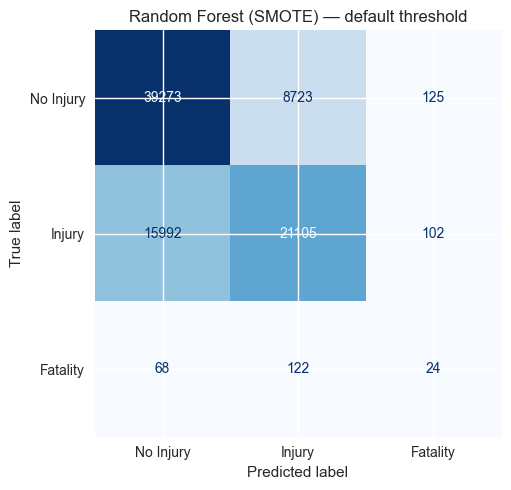

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_default)
ConfusionMatrixDisplay(cm, display_labels=['No Injury', 'Injury', 'Fatality']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest (SMOTE) — default threshold')
plt.tight_layout()
plt.show()

---
## 10. Threshold tuning for Fatality

The default 0.5 threshold means the model only predicts Fatality when it is very confident.  
Since catching fatal crashes matters more than avoiding false alarms, we lower the threshold.

We sweep from 0.01 → 0.5 and find the threshold that maximizes Fatality recall while keeping  
Fatality precision above 3% (so we're not drowning every crash in false positives).

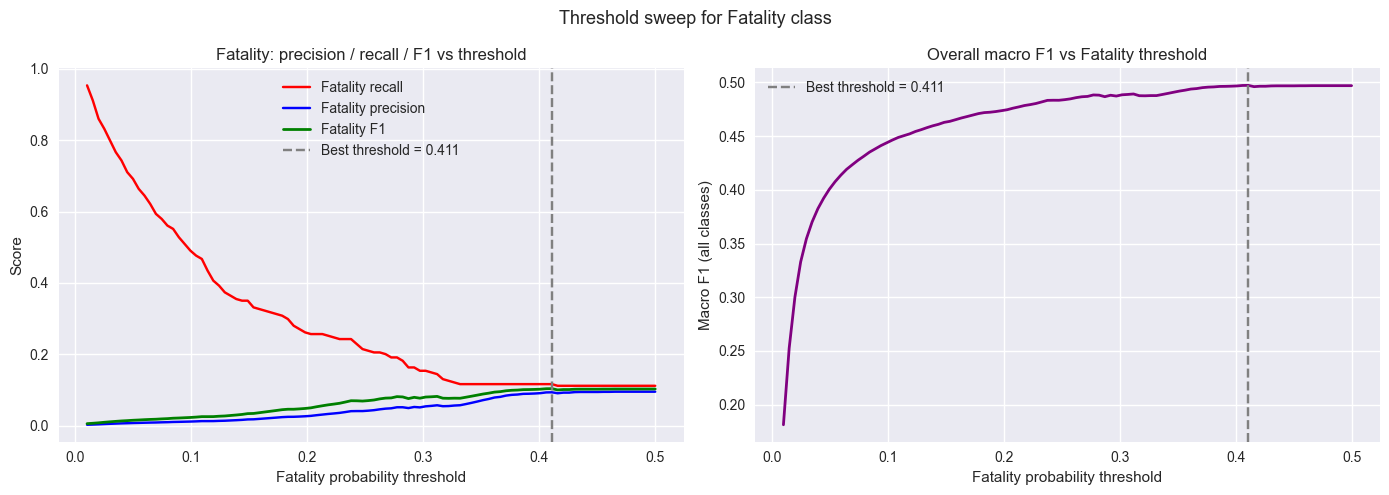

Best Fatality threshold: 0.4109
  Fatality recall @ best:    0.1168
  Fatality precision @ best: 0.0940
  Fatality F1 @ best:        0.1042
  Macro F1 @ best threshold: 0.4973


In [11]:
fatality_proba = y_proba[:, 2]  # P(Fatality) for each test sample

thresholds = np.linspace(0.01, 0.50, 100)
recalls, precisions, f1s, macro_f1s = [], [], [], []

for t in thresholds:
    # predict Fatality if P(Fatality) > t, else use argmax of remaining
    y_pred_t = np.where(fatality_proba >= t, 2, y_pred_default)
    recalls.append(recall_score(y_test, y_pred_t, labels=[2], average='macro', zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, labels=[2], average='macro', zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, labels=[2], average='macro', zero_division=0))
    macro_f1s.append(f1_score(y_test, y_pred_t, average='macro', zero_division=0))

recalls     = np.array(recalls)
precisions  = np.array(precisions)
f1s         = np.array(f1s)
macro_f1s   = np.array(macro_f1s)

# best threshold: maximize Fatality F1 (recall is primary but we need some precision)
best_idx   = np.argmax(f1s)
best_thresh = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresholds, recalls,    label='Fatality recall',    color='red')
ax.plot(thresholds, precisions, label='Fatality precision', color='blue')
ax.plot(thresholds, f1s,        label='Fatality F1',        color='green', linewidth=2)
ax.axvline(best_thresh, linestyle='--', color='gray', label=f'Best threshold = {best_thresh:.3f}')
ax.set_xlabel('Fatality probability threshold')
ax.set_ylabel('Score')
ax.set_title('Fatality: precision / recall / F1 vs threshold')
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(thresholds, macro_f1s, color='purple', linewidth=2)
ax.axvline(best_thresh, linestyle='--', color='gray', label=f'Best threshold = {best_thresh:.3f}')
ax.set_xlabel('Fatality probability threshold')
ax.set_ylabel('Macro F1 (all classes)')
ax.set_title('Overall macro F1 vs Fatality threshold')
ax.legend()
ax.grid(True)

plt.suptitle('Threshold sweep for Fatality class', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Best Fatality threshold: {best_thresh:.4f}")
print(f"  Fatality recall @ best:    {recalls[best_idx]:.4f}")
print(f"  Fatality precision @ best: {precisions[best_idx]:.4f}")
print(f"  Fatality F1 @ best:        {f1s[best_idx]:.4f}")
print(f"  Macro F1 @ best threshold: {macro_f1s[best_idx]:.4f}")

---
## 11. Evaluate with tuned threshold

In [12]:
y_pred_tuned = np.where(fatality_proba >= best_thresh, 2, y_pred_default)

print(f"=== Tuned threshold ({best_thresh:.4f}) ===")
print(classification_report(y_test, y_pred_tuned, target_names=['No Injury', 'Injury', 'Fatality']))
print(f"Macro F1:        {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_tuned, labels=[2], average='macro'):.4f}")
print(f"Fatality F1:     {f1_score(y_test, y_pred_tuned, labels=[2], average='macro'):.4f}")

=== Tuned threshold (0.4109) ===
              precision    recall  f1-score   support

   No Injury       0.71      0.82      0.76     48121
      Injury       0.70      0.57      0.63     37199
    Fatality       0.09      0.12      0.10       214

    accuracy                           0.71     85534
   macro avg       0.50      0.50      0.50     85534
weighted avg       0.71      0.71      0.70     85534

Macro F1:        0.4973
Fatality recall: 0.1168
Fatality F1:     0.1042


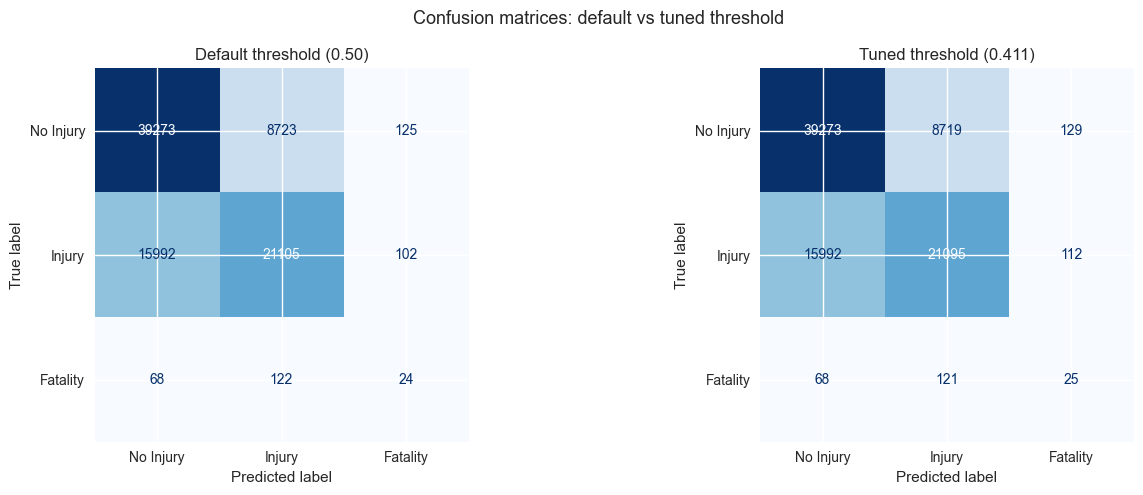

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_default, y_pred_tuned],
    [f'Default threshold (0.50)', f'Tuned threshold ({best_thresh:.3f})']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Injury', 'Injury', 'Fatality']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)

plt.suptitle('Confusion matrices: default vs tuned threshold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 12. Model comparison summary

How does this model compare to all previous versions?

In [14]:
summary = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)', 'Macro F1': 0.43, 'Fatality Recall': 0.00, 'Injury Recall': 0.43},
    {'Model': 'Random Forest v1 (same features)', 'Macro F1': 0.43, 'Fatality Recall': 0.00, 'Injury Recall': 0.43},
    {'Model': 'RF cleaner model (feature eng.)', 'Macro F1': 0.47, 'Fatality Recall': 0.20, 'Injury Recall': 0.56},
    {
        'Model': 'RF + SMOTE + features (default thresh)',
        'Macro F1': round(f1_score(y_test, y_pred_default, average='macro'), 4),
        'Fatality Recall': round(recall_score(y_test, y_pred_default, labels=[2], average='macro'), 4),
        'Injury Recall': round(recall_score(y_test, y_pred_default, labels=[1], average='macro'), 4),
    },
    {
        'Model': f'RF + SMOTE + features (tuned thresh={best_thresh:.3f})',
        'Macro F1': round(f1_score(y_test, y_pred_tuned, average='macro'), 4),
        'Fatality Recall': round(recall_score(y_test, y_pred_tuned, labels=[2], average='macro'), 4),
        'Injury Recall': round(recall_score(y_test, y_pred_tuned, labels=[1], average='macro'), 4),
    },
])

print(summary.to_string(index=False))

                                     Model  Macro F1  Fatality Recall  Injury Recall
            Logistic Regression (baseline)    0.4300           0.0000         0.4300
          Random Forest v1 (same features)    0.4300           0.0000         0.4300
           RF cleaner model (feature eng.)    0.4700           0.2000         0.5600
    RF + SMOTE + features (default thresh)    0.4970           0.1121         0.5674
RF + SMOTE + features (tuned thresh=0.411)    0.4973           0.1168         0.5671


---
## 13. Permutation importance (fixed)

Which features most impact macro F1 when shuffled? Run on the test set.

In [15]:
perm = permutation_importance(
    rf_final, X_test, y_test,
    scoring='f1_macro', n_repeats=8,
    random_state=RANDOM_STATE, n_jobs=-1
)
importance_df = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values(by='importance', ascending=False)

top = importance_df.head(15)
print(top.to_string(index=False))

                                           feature  importance      std
                          factor_vehicle_2_UNKNOWN    0.044085 0.002866
                      factor_vehicle_2_UNSPECIFIED    0.030977 0.002107
                      factor_vehicle_1_UNSPECIFIED    0.027917 0.002033
                                     bike_involved    0.027124 0.001592
                            vehicle_type_2_UNKNOWN    0.022443 0.003160
                              vehicle_type_1_SEDAN    0.019075 0.001327
                                   borough_UNKNOWN    0.018557 0.001930
                               motorcycle_involved    0.011857 0.000402
                     factor_vehicle_1_UNSAFE SPEED    0.011134 0.001066
vehicle_type_1_STATION WAGON/SPORT UTILITY VEHICLE    0.010379 0.001641
                                              hour    0.009188 0.001298
   factor_vehicle_1_DRIVER INATTENTION/DISTRACTION    0.006088 0.002025
                            time_of_day_late_night    0.005050 0

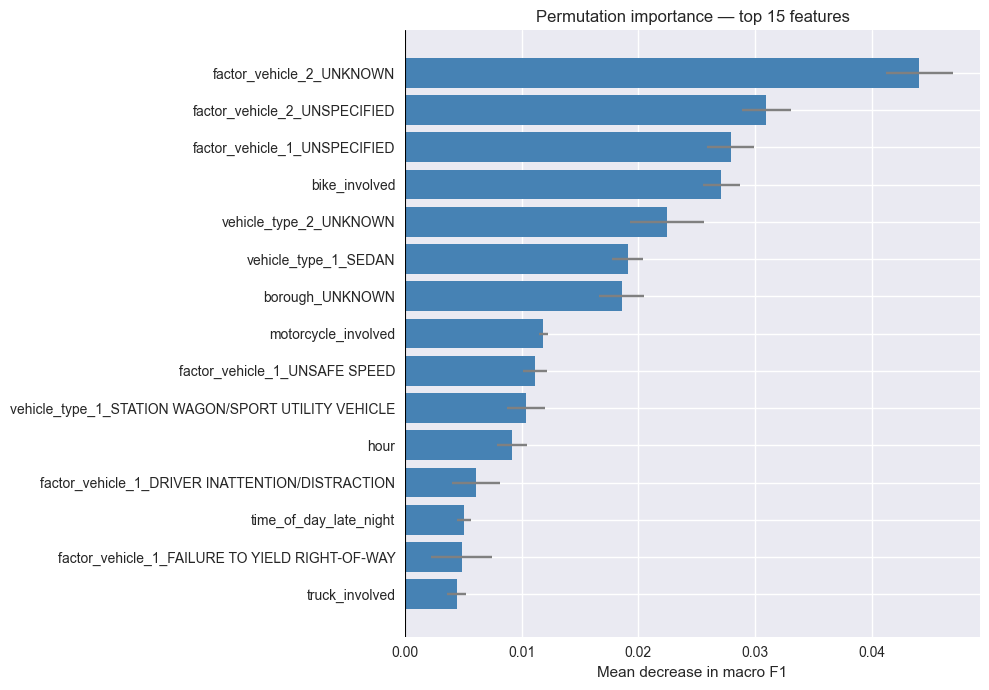

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top['feature'][::-1],
    top['importance'][::-1],
    xerr=top['std'][::-1],
    color='steelblue',
    ecolor='gray',
    capsize=3
)
ax.set_xlabel('Mean decrease in macro F1')
ax.set_title('Permutation importance — top 15 features')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 14. Next steps

If Fatality recall is still below ~40%, the recommended next experiments are:

1. **XGBoost with `scale_pos_weight`** — native imbalance handling, often outperforms RF on tabular data.
2. **SVM with RBF kernel** — can find non-linear Fatality clusters that RF splits miss; needs StandardScaler first.
3. **Two-stage model** — Train a binary Fatality vs. Not-Fatality detector first, then a No Injury vs. Injury classifier.
4. **More aggressive SMOTE** — try oversample target of 15,000–20,000 Fatality samples.
5. **Feature audit** — drop features with near-zero permutation importance from cell 13 to reduce noise.